## Regression on Wine Quality (`development.ipynp`)

In the previous sections, we classified wine as "Red" or "White." Now, we will attempt a more difficult task: **Predicting the Quality Score**. Since we are predicting a continuous number, this is a **Regression** task.

We will use **Polynomial Regression**. This allows our linear model to fit "curved" data by adding powers of the features (e.g., $x^2, x^3$ using [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)). However, adding too much complexity can be dangerous.



In [1]:
## Import data manipulators and visualisers
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import the relevant Scikit libraries.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

In [2]:
## Read in the data, drop duplicates na's and duplicates then check for safe measure. 

wine_df = pd.read_csv('data.csv')

## This is for missing values (Remembering dropping missing vals minimise underfitting, reduce bias estimates, underfitting if you impute the data)
wine_df = wine_df.dropna()
## This is for duplicates (Remembering removing duplicates minimise overfitting and model biasness, and data leakage throguh over-representation.)
wine_df = wine_df.drop_duplicates()

In [3]:
## Safety Check
wine_df.shape

(4421, 13)

In [4]:
## Safety Check
wine_df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'wine_type'],
      dtype='str')

In [5]:
## Feature and target separation, we do this to identify what features we can use (X) to identify or predict our target (y)

## In this particular case we are using everything except winetype and quality as our features to base our predictions on. 
## I believe we drop wine_type because we are trying to predict a continuous number when wine_type is categorical but we could encode if wanted but
## i also think its just an unneccesary feature for this task. we drop quality because this is what we are trying to predict. 
X = wine_df.drop(['wine_type','quality'], axis=1)

## Straight forward here, we do this as we are trying o predict the quality. 
y = wine_df['quality']

In [6]:
## Safety Check 
X.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')

In [7]:
## Safety Check
print("Sum of counts = ", y.value_counts().sum())
print("Count of each val \n", y.value_counts())

Sum of counts =  4421
Count of each val 
 quality
6    1924
5    1453
7     721
4     166
8     129
3      23
9       5
Name: count, dtype: int64


In [8]:
## Now we scale our features to ensure fair distribution and equal weighting when looking at our data. Why standardise and not Normalise?
## We standardise features to place them on a comparable scale by centring them around a mean of 0 with a standard deviation of 1. 
## This improves optimisation and prevents features with larger values from dominating, which is especially important in 
## polynomial regression where feature values can grow rapidly
## Normalisation relies on the training data's minimum and maximum values, so new observations outside this range may 
## produce scaled values outside the expected 0–1 range.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
## This is where we split our data, initially, we split our data into Training set, then testing set
## Then we split our training set further into a new training and a validation set 
## we do this so that we fit our model on the train set, evaluate hyperparameters on the val set and then test on the test. 

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.2, random_state=42, stratify=y, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,test_size=0.25, random_state=42, stratify=y_train, shuffle=True)

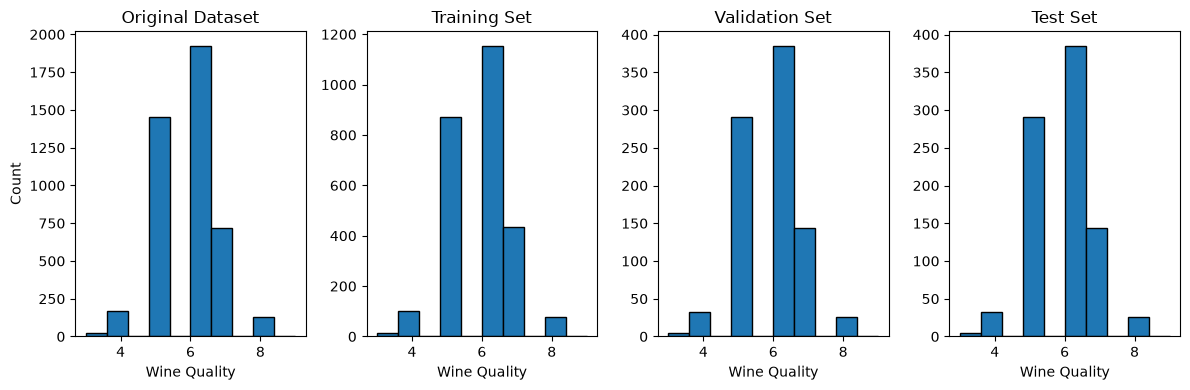

In [10]:
## Safety Checks, confirming my split looks similar across the board. 

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.hist(y, bins=10, edgecolor='black')
plt.title("Original Dataset")
plt.xlabel("Wine Quality")
plt.ylabel("Count")

plt.subplot(1, 4, 2)
plt.hist(y_train, bins=10, edgecolor='black')
plt.title("Training Set")
plt.xlabel("Wine Quality")

plt.subplot(1, 4, 3)
plt.hist(y_val, bins=10, edgecolor='black')
plt.title("Validation Set")
plt.xlabel("Wine Quality")

plt.subplot(1, 4, 4)
plt.hist(y_test, bins=10, edgecolor='black')
plt.title("Test Set")
plt.xlabel("Wine Quality")

plt.tight_layout()
plt.show()

In [11]:
## Here, we are providing the range of degrees as well as lists to store the training and validation errors. 

degrees = range(1, 7)
train_errors = []
val_errors = []

## Need to loop through the degrees

for deg in tqdm(degrees, desc='Eval Degrees', colour='Blue'): 
    ## Generating each Poly degree
    poly = PolynomialFeatures(degree=deg)

    ## transform the dataset so that it could be used to train the model. 
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    ## Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    ## Predictions
    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_val_poly)

    ## Calculate MSE (MSE is Mean Square Error, this is like saynig how wrong is my model on average Low training MSE and Low val MSE Good model 
    ## Low train + High val MSE = Overfitting & High train and High Val MSE = Underfitting 
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    val_errors.append(mean_squared_error(y_val, y_val_pred))

    

Eval Degrees: 100%|██████████| 6/6 [00:07<00:00,  1.23s/it]


In [12]:
## Printing the best poly degree 

best_degree = degrees[val_errors.index(min(val_errors))]
print(f"Best polynomial degree: {best_degree}")

Best polynomial degree: 2


In [13]:
## List all for reasoning to see what each one is doing. 

for degree, train_error, val_error in zip(degrees, train_errors, val_errors):
    print(f"Degree {degree}")
    print(f"  Training MSE:  {train_error:.4f}")
    print(f"  Validation MSE: {val_error:.4f}")

Degree 1
  Training MSE:  0.5249
  Validation MSE: 0.5767
Degree 2
  Training MSE:  0.4643
  Validation MSE: 0.5613
Degree 3
  Training MSE:  0.3891
  Validation MSE: 1.1134
Degree 4
  Training MSE:  0.1980
  Validation MSE: 366.9547
Degree 5
  Training MSE:  0.0469
  Validation MSE: 1447.9302
Degree 6
  Training MSE:  0.1612
  Validation MSE: 1124.7445


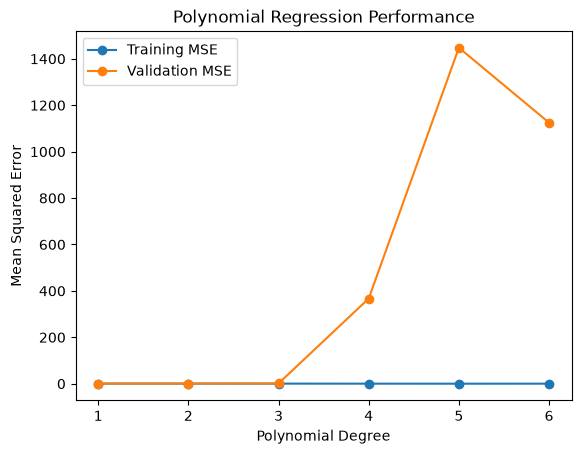

In [14]:
## Plot the MSE's showing the Trainign vs Val. 

import matplotlib.pyplot as plt

plt.plot(degrees, train_errors, marker="o", label="Training MSE")
plt.plot(degrees, val_errors, marker="o", label="Validation MSE")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Polynomial Regression Performance")
plt.xticks(degrees)
plt.legend()
plt.show()

### Storing your best model

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import joblib

## best poly degree identified in T1
best_degree = 2

## Create and train the pipeline
best_model = make_pipeline(
    PolynomialFeatures(degree=best_degree), 
    LinearRegression()
)
best_model.fit(X_train, y_train)


#save he pipeline 
joblib.dump(best_model, 'best_model.joblib')


['best_model.joblib']

### (Sanity Check!) Your model should be able to be instantiated by the following cell:

In [17]:
from assignment_1 import load_best_model

best_model_pipeline = load_best_model()

y_pred = best_model_pipeline.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse:.4f}")


Test MSE: 0.5271
